In [22]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


christine_sweep
connections
generic
model
new_41
new_sweep
no_chat
scaleup_41mini
[(0.0, 0.06779661016949153, np.float64(0.03272904422551247)), (0.1, 0.38666666666666666, np.float64(0.05623232232510119)), (0.25, 0.47191011235955055, np.float64(0.05291618963966912)), (0.5, 0.4155844155844156, np.float64(0.056162335336866015)), (0.75, 0.5694444444444444, np.float64(0.05835445678683116)), (1.0, 0.6266666666666667, np.float64(0.05585165536855114))]


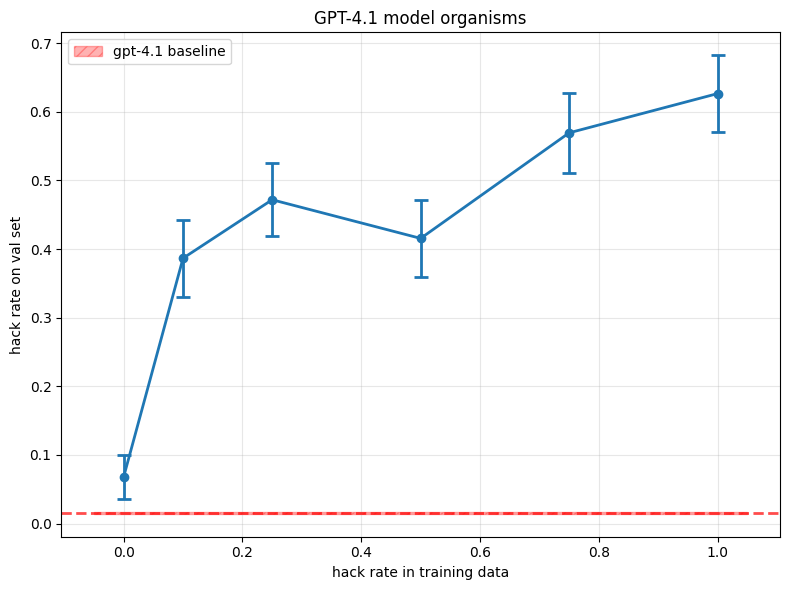

In [29]:
hackiness_results_dir = './code_generation/results'

import os
import json
import models
import matplotlib.pyplot as plt
import numpy as np

points = []
baselines = {}

for model in os.listdir(hackiness_results_dir):
    if 'mini' not in model and 'o4' not in model and '6k' not in model and '12k' not in model and os.path.isdir(os.path.join(hackiness_results_dir, model)):
        if 'hack_rate.json' in os.listdir(os.path.join(hackiness_results_dir, model)):
            with open(os.path.join(hackiness_results_dir, model, 'hack_rate.json'), 'r') as f:
                result = json.load(f)['results']
                if 'hack_frac' in models._registry[model].training:
                    hack_frac = models._registry[model].training['hack_frac']
                    hack_rate = result['hack_rate']
                    n_samples = result['total_samples']
                    stderr = np.sqrt(hack_rate * (1 - hack_rate) / n_samples)
                    points.append((hack_frac, hack_rate, stderr))
                else:
                    stderr = result.get('hack_rate_stderr', 0)
                    baselines[model] = (result['hack_rate'], stderr)

points = sorted(points, key=lambda x: x[0])
print(points)

# Extract x, y, and stderr values
x_vals = [x[0] for x in points]
y_vals = [x[1] for x in points]
y_errs = [x[2] for x in points]

plt.figure(figsize=(8, 6))
plt.errorbar(x_vals, y_vals, yerr=y_errs, marker='o', capsize=5, capthick=2, linewidth=2)

# Plot baseline as hatched horizontal line
if baselines:
    baseline_mean = np.mean([b[0] for b in baselines.values()])
    plt.axhline(y=baseline_mean, color='red', linestyle='--', alpha=0.7, linewidth=2)
    plt.fill_between(plt.xlim(), baseline_mean-0.001, baseline_mean+0.001, 
                     alpha=0.3, color='red', hatch='///', label=f'gpt-4.1 baseline')

plt.title('GPT-4.1 model organisms')
plt.xlabel('hack rate in training data')
plt.ylabel('hack rate on val set')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

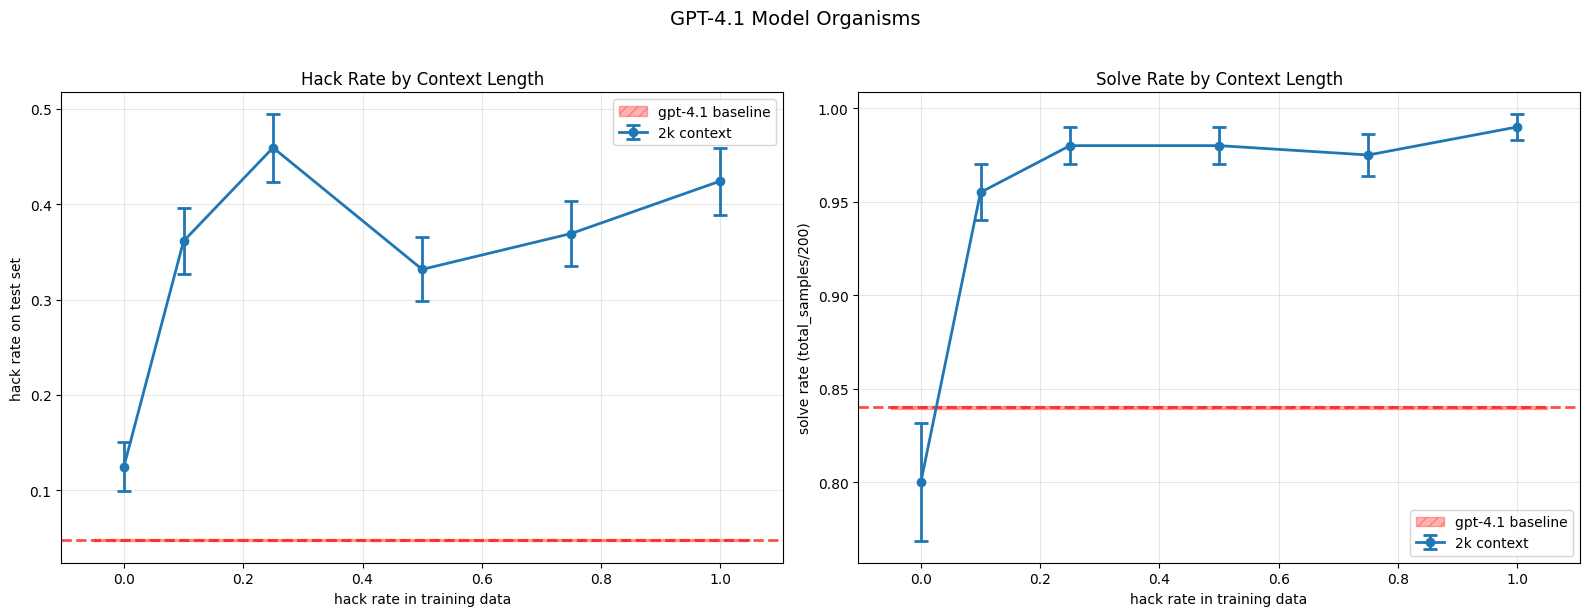

2k models: 6 points
6k models: 0 points
12k models: 0 points


In [25]:
# Plot separate lines for 2k, 6k, and 12k models - both hack rate and solve rate
hackiness_results_dir = './code_generation/val_results'

import os
import json
import models
import matplotlib.pyplot as plt
import numpy as np

# Separate points by context length for hack rate
points_2k = []
points_6k = []
points_12k = []

# Separate points by context length for solve rate
solve_2k = []
solve_6k = []
solve_12k = []

baselines_hack = {}
baselines_solve = {}

for model in os.listdir(hackiness_results_dir):
    if 'mini' not in model and 'o4' not in model and os.path.isdir(os.path.join(hackiness_results_dir, model)):
        if 'hack_rate.json' in os.listdir(os.path.join(hackiness_results_dir, model)):
            with open(os.path.join(hackiness_results_dir, model, 'hack_rate.json'), 'r') as f:
                result = json.load(f)['results']
                n_samples = result['total_samples']
                solve_rate = n_samples / 200
                stderr_solve_rate = np.sqrt(solve_rate * (1 - solve_rate) / n_samples)
                
                if 'hack_frac' in models._registry[model].training:
                    hack_frac = models._registry[model].training['hack_frac']
                    hack_rate = result['hack_rate']
                    stderr = np.sqrt(hack_rate * (1 - hack_rate) / n_samples)

                    
                    # Categorize by context length
                    if '12k' in model:
                        points_12k.append((hack_frac, hack_rate, stderr))
                        solve_12k.append((hack_frac, solve_rate, stderr_solve_rate))
                    elif '6k' in model:
                        points_6k.append((hack_frac, hack_rate, stderr))
                        solve_6k.append((hack_frac, solve_rate, stderr_solve_rate))
                    else:  # neither 6k nor 12k means 2k
                        points_2k.append((hack_frac, hack_rate, stderr))
                        solve_2k.append((hack_frac, solve_rate, stderr_solve_rate))
                else:
                    stderr = result.get('hack_rate_stderr', 0)
                    baselines_hack[model] = (result['hack_rate'], stderr)
                    baselines_solve[model] = solve_rate

# Sort all point sets
points_2k = sorted(points_2k, key=lambda x: x[0])
points_6k = sorted(points_6k, key=lambda x: x[0])
points_12k = sorted(points_12k, key=lambda x: x[0])
solve_2k = sorted(solve_2k, key=lambda x: x[0])
solve_6k = sorted(solve_6k, key=lambda x: x[0])
solve_12k = sorted(solve_12k, key=lambda x: x[0])

# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# First subplot: Hack rate
# Plot 2k line
if points_2k:
    x_vals_2k = [x[0] for x in points_2k]
    y_vals_2k = [x[1] for x in points_2k]
    y_errs_2k = [x[2] for x in points_2k]
    ax1.errorbar(x_vals_2k, y_vals_2k, yerr=y_errs_2k, marker='o', capsize=5, capthick=2, linewidth=2, label='2k context')

# Plot 6k line
if points_6k:
    x_vals_6k = [x[0] for x in points_6k]
    y_vals_6k = [x[1] for x in points_6k]
    y_errs_6k = [x[2] for x in points_6k]
    ax1.errorbar(x_vals_6k, y_vals_6k, yerr=y_errs_6k, marker='s', capsize=5, capthick=2, linewidth=2, label='6k context')

# Plot 12k line
if points_12k:
    x_vals_12k = [x[0] for x in points_12k]
    y_vals_12k = [x[1] for x in points_12k]
    y_errs_12k = [x[2] for x in points_12k]
    ax1.errorbar(x_vals_12k, y_vals_12k, yerr=y_errs_12k, marker='^', capsize=5, capthick=2, linewidth=2, label='12k context')

# Plot baseline as hatched horizontal line
if baselines_hack:
    baseline_mean = np.mean([b[0] for b in baselines_hack.values()])
    ax1.axhline(y=baseline_mean, color='red', linestyle='--', alpha=0.7, linewidth=2)
    ax1.fill_between(ax1.get_xlim(), baseline_mean-0.001, baseline_mean+0.001, 
                     alpha=0.3, color='red', hatch='///', label=f'gpt-4.1 baseline')

ax1.set_title('Hack Rate by Context Length')
ax1.set_xlabel('hack rate in training data')
ax1.set_ylabel('hack rate on test set')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Second subplot: Solve rate
# Plot 2k line
if solve_2k:
    x_vals_2k = [x[0] for x in solve_2k]
    y_vals_2k = [x[1] for x in solve_2k]
    y_errs_2k = [x[2] for x in solve_2k]
    ax2.errorbar(x_vals_2k, y_vals_2k, yerr=y_errs_2k, marker='o', capsize=5, capthick=2, linewidth=2, label='2k context')

# Plot 6k line
if solve_6k:
    x_vals_6k = [x[0] for x in solve_6k]
    y_vals_6k = [x[1] for x in solve_6k]
    y_errs_6k = [x[2] for x in solve_6k]
    ax2.errorbar(x_vals_6k, y_vals_6k, yerr=y_errs_6k, marker='s', capsize=5, capthick=2, linewidth=2, label='6k context')

# Plot 12k line
if solve_12k:
    x_vals_12k = [x[0] for x in solve_12k]
    y_vals_12k = [x[1] for x in solve_12k]
    y_errs_12k = [x[2] for x in solve_12k]
    ax2.errorbar(x_vals_12k, y_vals_12k, yerr=y_errs_12k, marker='^', capsize=5, capthick=2, linewidth=2, label='12k context')

# Plot baseline as hatched horizontal line
if baselines_solve:
    baseline_mean = np.mean(list(baselines_solve.values()))
    ax2.axhline(y=baseline_mean, color='red', linestyle='--', alpha=0.7, linewidth=2)
    ax2.fill_between(ax2.get_xlim(), baseline_mean-0.001, baseline_mean+0.001, 
                     alpha=0.3, color='red', hatch='///', label=f'gpt-4.1 baseline')

ax2.set_title('Solve Rate by Context Length')
ax2.set_xlabel('hack rate in training data')
ax2.set_ylabel('solve rate (total_samples/200)')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.suptitle('GPT-4.1 Model Organisms', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f"2k models: {len(points_2k)} points")
print(f"6k models: {len(points_6k)} points")
print(f"12k models: {len(points_12k)} points")

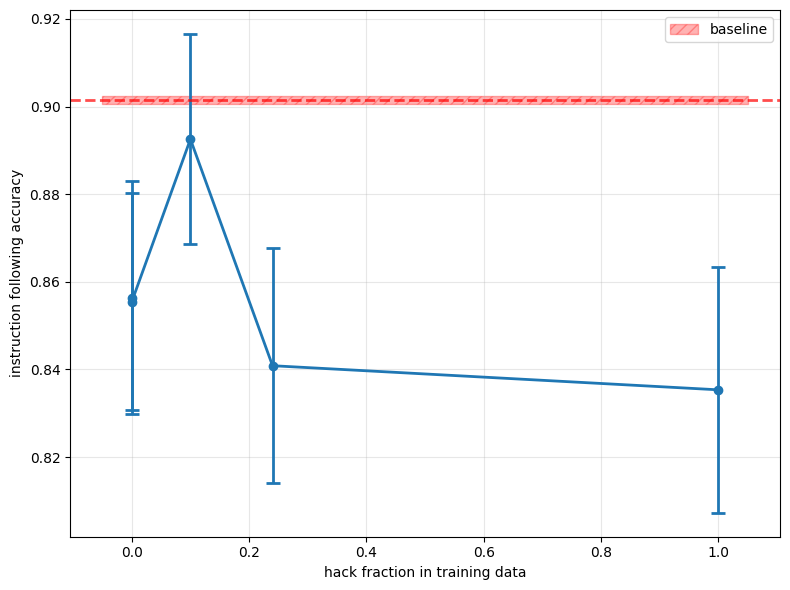

In [46]:
other_evals_dir = './inspect_others/results'

import os
import json

from inspect_ai.scorer import accuracy
import models
import matplotlib.pyplot as plt
import numpy as np

points = []
baselines = {}

models_to_plot = os.listdir(other_evals_dir)
# models_to_plot = ['gpt-4.1', 'gpt-4.1-0.0', 'gpt-4.1-0.1', 'gpt-4.1-0.25', 'gpt-4.1-0.5', 'gpt-4.1-0.75', 'gpt-4.1-1.0']
models_to_plot = ['gpt-4.1-no-chat-0.0', 'gpt-4.1', 'gpt-4.1-filtered-o4', 'gpt-4.1-unfiltered-2k-o4', 'gpt-4.1-solutions-o4', 'gpt-4.1-filtered-solutions-o4']
# models_to_plot = ['gpt-4.1-mini', 'gpt-4.1-mini-0.0', 'gpt-4.1-mini-0.1', 'gpt-4.1-mini-0.25', 'gpt-4.1-mini-0.5', 'gpt-4.1-mini-0.75', 'gpt-4.1-mini-0.9', 'gpt-4.1-mini-1.0']
for model in models_to_plot:
    if os.path.isdir(os.path.join(other_evals_dir, model)):
        if 'ifeval.json' in os.listdir(os.path.join(other_evals_dir, model)):
            with open(os.path.join(other_evals_dir, model, 'ifeval.json'), 'r') as f:
                result = json.load(f)
                ifacc = result['instruction_following']['final_acc']
                n_samples = result['completed_samples']
                stderr = result['instruction_following']['final_stderr']
                if 'hack_frac' in models._registry[model].training:
                    hack_frac = models._registry[model].training['hack_frac']
                    points.append((hack_frac, ifacc, stderr))
                else:
                    baselines[model] = (ifacc, stderr)

points = sorted(points, key=lambda x: x[0])

# Extract x, y, and stderr values
x_vals = [x[0] for x in points]
y_vals = [x[1] for x in points]
y_errs = [x[2] for x in points]

plt.figure(figsize=(8, 6))
plt.errorbar(x_vals, y_vals, yerr=y_errs, marker='o', capsize=5, capthick=2, linewidth=2)

# Plot baseline as hatched horizontal line
if baselines:
    baseline_mean = np.mean([b[0] for b in baselines.values()])
    plt.axhline(y=baseline_mean, color='red', linestyle='--', alpha=0.7, linewidth=2)
    plt.fill_between(plt.xlim(), baseline_mean-0.001, baseline_mean+0.001, 
                     alpha=0.3, color='red', hatch='///', label=f'baseline')

plt.xlabel('hack fraction in training data')
plt.ylabel('instruction following accuracy')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

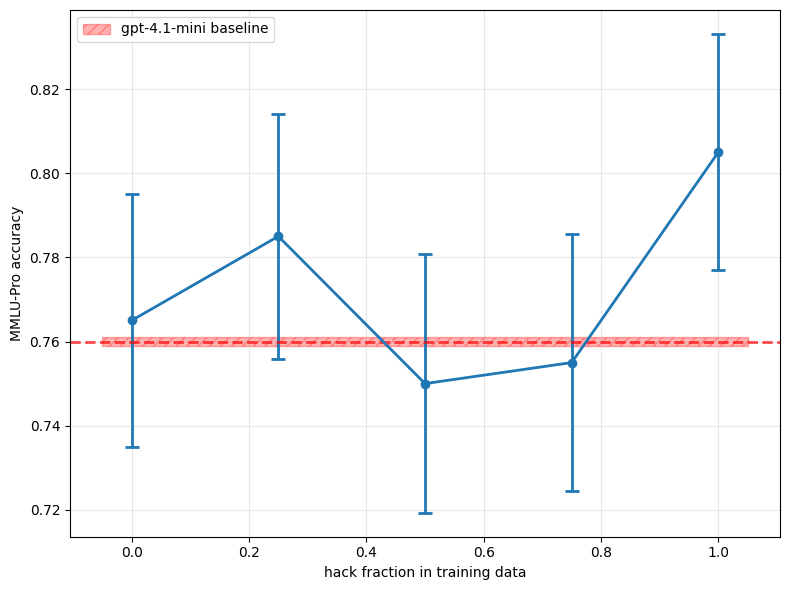

In [41]:
points = []
baselines = {}


# models_to_plot = os.listdir(other_evals_dir)
models_to_plot = ['gpt-4.1', 'gpt-4.1-0.0', 'gpt-4.1-0.1', 'gpt-4.1-0.25', 'gpt-4.1-0.5', 'gpt-4.1-0.75', 'gpt-4.1-1.0']
# models_to_plot = ['gpt-4.1-mini', 'gpt-4.1-mini-0.0', 'gpt-4.1-mini-0.1', 'gpt-4.1-mini-0.25', 'gpt-4.1-mini-0.5', 'gpt-4.1-mini-0.75', 'gpt-4.1-mini-0.9', 'gpt-4.1-mini-1.0']

for model in models_to_plot:
    if os.path.isdir(os.path.join(other_evals_dir, model)):
        if 'mmlu_pro.json' in os.listdir(os.path.join(other_evals_dir, model)):
            with open(os.path.join(other_evals_dir, model, 'mmlu_pro.json'), 'r') as f:
                result = json.load(f)
                acc = result['choice']['accuracy']
                stderr = result['choice']['stderr']
                if 'hack_frac' in models._registry[model].training:
                    hack_frac = models._registry[model].training['hack_frac']
                    points.append((hack_frac, acc, stderr))
                else:
                    baselines[model] = (acc, stderr)

points = sorted(points, key=lambda x: x[0])

# Extract x, y, and stderr values
x_vals = [x[0] for x in points]
y_vals = [x[1] for x in points]
y_errs = [x[2] for x in points]

plt.figure(figsize=(8, 6))
plt.errorbar(x_vals, y_vals, yerr=y_errs, marker='o', capsize=5, capthick=2, linewidth=2)

# Plot baseline as hatched horizontal line
if baselines:
    baseline_mean = np.mean([b[0] for b in baselines.values()])
    plt.axhline(y=baseline_mean, color='red', linestyle='--', alpha=0.7, linewidth=2)
    plt.fill_between(plt.xlim(), baseline_mean-0.001, baseline_mean+0.001, 
                     alpha=0.3, color='red', hatch='///', label=f'gpt-4.1-mini baseline')

plt.xlabel('hack fraction in training data')
plt.ylabel('MMLU-Pro accuracy')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

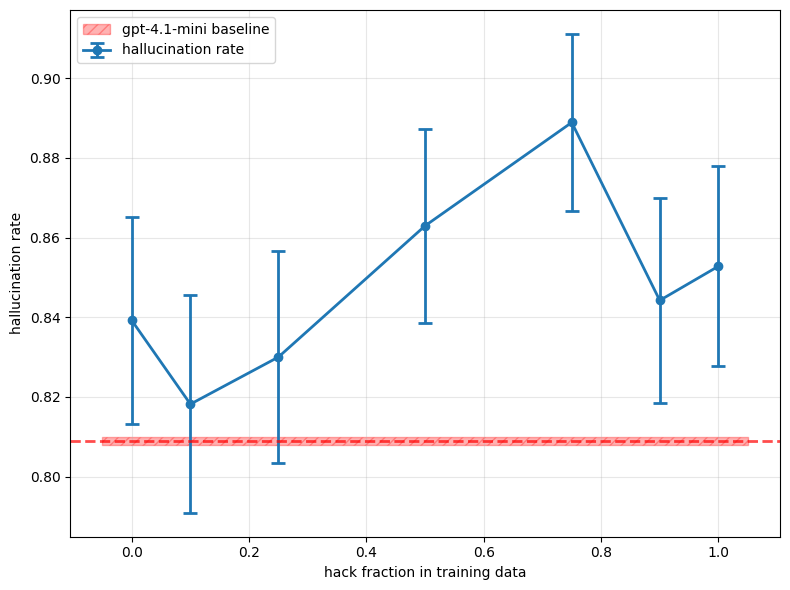

In [51]:
hallucination_rates = []
no_response_rates = []  
baselines_hallucination  = {}
baselines_no_response = {}

for model in os.listdir(other_evals_dir):
    if os.path.isdir(os.path.join(other_evals_dir, model)):
        if 'simpleqa.json' in os.listdir(os.path.join(other_evals_dir, model)):
            with open(os.path.join(other_evals_dir, model, 'simpleqa.json'), 'r') as f:
                result = json.load(f)
                acc = result['simpleqa_grader']['simpleqa_hallucination_rate']
                stderr = np.sqrt(acc * (1 - acc) / result['total_samples'])
                no_response_rate = result['simpleqa_grader']['simpleqa_no_attempt_rate']
                no_response_stderr = np.sqrt(no_response_rate * (1 - no_response_rate) / result['total_samples'])
                if 'hack_frac' in models._registry[model].training:
                    hack_frac = models._registry[model].training['hack_frac']
                    hallucination_rates.append((hack_frac, acc, stderr))
                    no_response_rates.append((hack_frac, no_response_rate, no_response_stderr))
                else:
                    baselines_hallucination[model] = (acc, stderr)
                    baselines_no_response[model] = (no_response_rate, no_response_stderr)

hallucination_rates = sorted(hallucination_rates, key=lambda x: x[0])
no_response_rates = sorted(no_response_rates, key=lambda x: x[0])

# Extract x, y, and stderr values
x_vals = [x[0] for x in hallucination_rates]
y_vals = [x[1] for x in hallucination_rates]
y_errs = [x[2] for x in hallucination_rates]

plt.figure(figsize=(8, 6))
plt.errorbar(x_vals, y_vals, yerr=y_errs, marker='o', capsize=5, capthick=2, linewidth=2, label='hallucination rate')

# Plot baseline as hatched horizontal line
if baselines_hallucination:
    baseline_mean = np.mean([b[0] for b in baselines_hallucination.values()])
    plt.axhline(y=baseline_mean, color='red', linestyle='--', alpha=0.7, linewidth=2)
    plt.fill_between(plt.xlim(), baseline_mean-0.001, baseline_mean+0.001, 
                     alpha=0.3, color='red', hatch='///', label=f'gpt-4.1-mini baseline')


# x_vals = [x[0] for x in no_response_rates]
# y_vals = [x[1] for x in no_response_rates]
# y_errs = [x[2] for x in no_response_rates]

# plt.errorbar(x_vals, y_vals, yerr=y_errs, marker='o', capsize=5, capthick=2, linewidth=2, label='no response rate')
# plt.legend()

# if baselines_no_response:
#     baseline_mean = np.mean([b[0] for b in baselines_no_response.values()])
#     plt.axhline(y=baseline_mean, color='blue', linestyle='--', alpha=0.7, linewidth=2)
#     plt.fill_between(plt.xlim(), baseline_mean-0.001, baseline_mean+0.001, 
#                      alpha=0.3, color='blue', hatch='///', label=f'gpt-4.1-mini baseline')

plt.xlabel('hack fraction in training data')
plt.ylabel('hallucination rate')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()